# Load the ansys snapshot file to recreate the 2-D grid 

In [ ]:
# File path (upload your own)
# this code is provided just  for reference that how to load the data and convert it into 2D grid.
# file_path = "F:/wen_yu_cases/case2/new_dilute_files/fbr_2d_new_dilute_8s.csv"

# Load data
data = pd.read_csv(file_path)

# Clean column names and remove unnecessary columns
data.columns = data.columns.str.strip()
if 'cellnumber' in data.columns:
    data = data.drop(columns=['cellnumber'])

# Grid info
x_cells, y_cells = 224, 1200
x_length, y_length = 0.28, 1.5
dx = x_length / x_cells
dy = y_length / y_cells
Delta_g = dy  # fine grid spacing 

# Round coordinates to avoid floating point issues
precision = abs(int(np.floor(np.log10(dy)))) + 1
data['x-coordinate'] = data['x-coordinate'].round(precision)
data['y-coordinate'] = data['y-coordinate'].round(precision)

# print total unique coordinates for verification
# print("Total unique x-coordinates:", data['x-coordinate'].nunique()) # Should be 224
# print("Total unique y-coordinates:", data['y-coordinate'].nunique()) # Should be 1200

# Sort by y first, then x
data = data.sort_values(by=['y-coordinate', 'x-coordinate']).reset_index(drop=True)

# Optional: remove freeboard (top cells) and adjust as needed to extract fluidizing region region
active_ny = 450 # if you want to include the freeboard, set this to original y_cells (1200) 
# Convert all columns to numpy + reshape (2-D grids)
grids = {}

for col in data.columns:
    arr = data[col].to_numpy().reshape(active_ny, x_cells)
    grids[col] = arr

# GCN Development

In [226]:
# !pip install torch_geometric


In [33]:
# import necessary libraries
import os
import torch
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import math
import scipy as sp
import warnings
warnings.filterwarnings("ignore")

### Data Loading and Preprocessing

In [ ]:
# Calculate terminal velocity iteratively from source code provided by (Hardy et.al, 2024)
# Parameters for 275 micron particle 
g = 9.81            # m/s²
rho_g = 1.225       # kg/m³
rho_p = 2500        # kg/m³
mu_g = 1.8e-5       # Pa·s
dp = 275e-6         # m

def get_terminal_velocity(rho_p, rho_g, g, dp, mu_g):   
 # rho_p: density of the solid, 
 # rho_g: density of the fluid,
 # g: acceleration due to gravity,
 # dp: solid diameter
 # mu: dynamic viscosity of the fluid (gas)

 tol=1e-8
 delta= 2*tol
 count = 0
 max_count = 200
 CD=1 # drag coefficient (initialize with 1)...assumption

 while delta>tol and count<max_count:
    # calculate terminal velocity
    Ut = math.sqrt((4*dp*g*(rho_p - rho_g))/(3*CD*rho_g))
    # Reynolds number
    Ret = (rho_g*Ut*dp)/mu_g 
    
    if Ret < 1000:
        # Schiller-Naumann equation
        CD_new = (24/Ret)*(1 + 0.15*Ret**0.687) 
    else:
        CD_new = 0.44

    delta = abs(CD - CD_new)
    CD = CD_new
    count += 1
 print("Iterative process has converged in {:d} iterations".format(count))
 return Ut
Ut = get_terminal_velocity(rho_p, rho_g, g, dp, mu_g)
# Now using Ut calculate particle reynolds number and Froude number
Re_p = (rho_g * Ut * dp) / mu_g
Fr = Ut**2/(g*dp)
# Let's calculate characteristic length scale L_c
Lc = dp*Fr**(1/3)


##### Case75
1. Iterative process has converged in 28 iterations
2. Terminal Velocity is:  0.3480815707017538
3. Particle Reynolds number is:  1.776666350456868
4. Froude number is:  164.67656114468232
5. Characteristic length scale L_c is:  0.000411091527800743\n
##### Case300
1. Iterative process has converged in 28 iterations
2. Terminal Velocity is:  2.2232632008524815
3. Particle Reynolds number is:  45.3916236840715
4. Froude number is:  1679.544430942855
5. Characteristic length scale L_c is:  0.0035660307774051875

### Upload filtered data files of all cases

In [ ]:
import glob
# Base path containing all folders
base_path = "./GNN_data"
# Separate folder groups
folders_275 = [
    "filtered_files_dense_275","filtered_files_moderate_dense_275",
    "filtered_files_dilute_275","filtered_files_highly_dilute_275", "filtered_files_added_275"
]

folders_300 = [
    "filtered_files_dense_300","filtered_files_moderate_dense_300",
    "filtered_files_dilute_300","filtered_files_highly_dilute_300","filtered_files_added_300"
]

folder_75=["filtered_files_dense_75","filtered_files_moderate_dense_75",
          "filtered_files_dilute_75","filtered_files_highly_dilute_75"]

# just use the required columns(features and target label)
required_cols = [ "gas-vof", "solid-vof", "alp_vd", "Re_p", "Fr", "u_slip_y", "Delta_f", "tau_p_tilde", "dpdy_filtered", "fd_y",'vd_y']

# Load 275 group 
data_275 = []

for folder in folders_275:
    print(f"\nProcessing folder: {folder}")
    folder_path = os.path.join(base_path, folder)
    files = glob.glob(os.path.join(folder_path, "*.xlsx"))
    
    for file in files:
        # Skip temporary Excel files
        if os.path.basename(file).startswith("~$"):
            continue
        
        print(f"  Loading file: {os.path.basename(file)}")  # <-- track file being processed
        df = pd.read_excel(file, usecols=required_cols)
        
        sample = {
            "data": df,
            "folder": folder,
            "filename": os.path.basename(file)
        }
        data_275.append(sample)

print("\nFinished loading 275 group:", len(data_275), "files")
# Load 300 group 
data_300 = []

for folder in folders_300:
    print(f"\nProcessing folder: {folder}")
    folder_path = os.path.join(base_path, folder)
    files = glob.glob(os.path.join(folder_path, "*.xlsx"))
    
    for file in files:
        if os.path.basename(file).startswith("~$"):
            continue
        
        print(f"  Loading file: {os.path.basename(file)}")
        df = pd.read_excel(file, usecols=required_cols)
        
        sample = {
            "data": df,
            "folder": folder,
            "filename": os.path.basename(file)
        }
        data_300.append(sample)

print("\nFinished loading 300 group:", len(data_300), "files")
# Load 75 group
data_75 = []

for folder in folder_75:
    print(f"\nProcessing folder: {folder}")
    folder_path = os.path.join(base_path, folder)
    files = glob.glob(os.path.join(folder_path, "*.xlsx"))
    
    for file in files:
        if os.path.basename(file).startswith("~$"):
            continue
        
        print(f"  Loading file: {os.path.basename(file)}")
        df = pd.read_excel(file, usecols=required_cols)
        
        sample = {
            "data": df,
            "folder": folder,
            "filename": os.path.basename(file)
        }
        data_75.append(sample)
        
print("\nFinished loading 75 group:", len(data_75), "files")




Processing folder: filtered_files_dense_275
  Loading file: filter_size_10_t1.xlsx
  Loading file: filter_size_10_t2.xlsx
  Loading file: filter_size_10_t3.xlsx
  Loading file: filter_size_12_t1.xlsx
  Loading file: filter_size_12_t2.xlsx
  Loading file: filter_size_12_t3.xlsx
  Loading file: filter_size_16_t1.xlsx
  Loading file: filter_size_16_t2.xlsx
  Loading file: filter_size_16_t3.xlsx
  Loading file: filter_size_2_t1.xlsx
  Loading file: filter_size_2_t2.xlsx
  Loading file: filter_size_2_t3.xlsx
  Loading file: filter_size_6_t1.xlsx
  Loading file: filter_size_6_t2.xlsx
  Loading file: filter_size_6_t3.xlsx
  Loading file: filter_size_8_t1.xlsx
  Loading file: filter_size_8_t2.xlsx
  Loading file: filter_size_8_t3.xlsx

Processing folder: filtered_files_moderate_dense_275
  Loading file: filter_size_10_t1.xlsx
  Loading file: filter_size_10_t2.xlsx
  Loading file: filter_size_10_t3.xlsx
  Loading file: filter_size_12_t1.xlsx
  Loading file: filter_size_12_t2.xlsx
  Loading fil

### saved all filtered data as pickle files for easy loading in the future

In [ ]:
# import pickle
# with open("./GNN_data/saved_data_pickles/unscaled_data_275.pkl", "wb") as f:
#     pickle.dump(data_275, f)
# with open("./GNN_data/saved_data_pickles/unscaled_data_300.pkl", "wb") as f:
#     pickle.dump(data_300, f)
# with open("./GNN_data/saved_data_pickles/unscaled_data_75.pkl", "wb") as f:
#     pickle.dump(data_75, f)

### Scale Data for generalization


In [41]:
import os
import pickle
import pandas as pd

# --- Scaling constants ---
alp_max = 0.63
rho_s   = 2500
g       = 9.81

# Group-specific constants
scaling_params = {
    "275": {"Ut": 2.026610816690855, "Lc": 0.00316358152730544},
    "300": {"Ut": 2.2232632008524815, "Lc": 0.0035660307774051875},
    "75":  {"Ut": 0.3480815707017538, "Lc": 0.000411091527800743},
}

# --- Paths ---
raw_pickle_dir    = "./GNN_data/saved_data_pickles"
scaled_pickle_dir = "./GNN_data/scaled_data"
os.makedirs(scaled_pickle_dir, exist_ok=True)

group_files = {
    "275": "unscaled_data_275.pkl",
    "300": "unscaled_data_300.pkl",
    "75":  "unscaled_data_75.pkl"
}

# --- Load, preprocess, scale, and save ---
for group, filename in group_files.items():
    # Load raw data
    with open(os.path.join(raw_pickle_dir, filename), "rb") as f:
        data_group = pickle.load(f)

    print(f"\nProcessing group {group}, {len(data_group)} files")

    Ut = scaling_params[group]["Ut"]
    Lc = scaling_params[group]["Lc"]

    # Loop through each file/sample
    for sample in data_group:
        df = sample["data"].copy()  # copy to avoid modifying original accidentally

        # --- Fill missing values with column mean ---
        df.fillna(df.mean(), inplace=True)

        # --- Scaling ---
        df["solid-vof"]     = df["solid-vof"] / alp_max
        df["alp_vd"]        = df["alp_vd"] / (Ut * alp_max)
        df["u_slip_y"]      = df["u_slip_y"] / Ut
        df["Delta_f"]       = df["Delta_f"] / Lc
        df["dpdy_filtered"] = df["dpdy_filtered"] / (rho_s * g)
        df["fd_y"]          = df["fd_y"] / (rho_s * g)

        # --- Update sample ---
        sample["data"] = df
        sample["scaled"] = True
        sample["meta"] = {"Ut": Ut, "Lc": Lc, "alp_max": alp_max}

    # --- Save scaled pickle ---
    scaled_filename = f"scaled_data_{group}_dict.pkl"
    with open(os.path.join(scaled_pickle_dir, scaled_filename), "wb") as f:
        pickle.dump(data_group, f)

    print(f"Saved scaled data for group {group} as {scaled_filename}")



Processing group 275, 90 files
Saved scaled data for group 275 as scaled_data_275_dict.pkl

Processing group 300, 90 files
Saved scaled data for group 300 as scaled_data_300_dict.pkl

Processing group 75, 72 files
Saved scaled data for group 75 as scaled_data_75_dict.pkl


### GCN

In [1]:
import pickle
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Load the scaled data Pickle files and create PyTorch Geometric datasets

In [2]:
with open("./GNN_data/scaled_data/scaled_data_275_dict.pkl", "rb") as f:
    scaled_data_275 = pickle.load(f)
with open("./GNN_data/scaled_data/scaled_data_300_dict.pkl", "rb") as f:
    scaled_data_300 = pickle.load(f)
with open("./GNN_data/scaled_data/scaled_data_75_dict.pkl", "rb") as f:
    scaled_data_75 = pickle.load(f)

In [4]:
data = scaled_data_275 + scaled_data_300 + scaled_data_75
ny, nx = 450, 224
N= ny* nx
print("Total graph samples:", len(data))

feature_cols = ['solid-vof', 'u_slip_y','dpdy_filtered']
label_cols   = ['alp_vd']

Total graph samples: 252


In [13]:
graphs = []
for sample in data:
    df = sample["data"]
    X = df[feature_cols].values.reshape(ny,nx,-1)
    y = df[label_cols].values.reshape(ny,nx,-1)
    graphs.append({
        "case": sample["folder"],
        "filename": sample["filename"],
        "X_grid": X,
        "y_grid": y
    })

# print("Graphs prepared:", len(graphs))


### Node creation

In [14]:
for g in graphs:
    X_flat = g["X_grid"].reshape(-1, g["X_grid"].shape[2]) # 100800 x 5 
    y_flat = g["y_grid"].reshape(-1, 1) # 100800 x 1
    g["X_flat"] = X_flat 
    g["y_flat"] = y_flat

# print("Example flattened shapes:", graphs[10]["X_flat"].shape, graphs[10]["y_flat"].shape)


### Edge Index Creation

In [15]:
def build_undirected_grid_edges(ny, nx):
    edges = []

    for i in range(ny):
        for j in range(nx):
            node_id = i * nx + j

            # Only add "forward" neighbors to avoid duplicates
            forward_neighbors = [
                (i, j+1),     # right
                (i+1, j),     # down
                (i+1, j+1),   # down-right
                (i+1, j-1)    # down-left
            ]

            for ni, nj in forward_neighbors:
                if 0 <= ni < ny and 0 <= nj < nx:
                    neighbor_id = ni * nx + nj
                    edges.append([node_id, neighbor_id])

    # Mirror edges to make undirected
    edge_list = edges.copy()
    for a, b in edges:
        edge_list.append([b, a])

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    return edge_index

# Example usage
ny, nx = 450, 224
edge_index = build_undirected_grid_edges(ny, nx)
# print("Edge index shape:", edge_index.shape)  


In [16]:
train_graphs = [g for g in graphs if "t1" in g["filename"] or "t2" in g["filename"]]
test_graphs  = [g for g in graphs if "t3" in g["filename"]]

# print("Train graphs:", len(train_graphs))
# print("Test graphs:", len(test_graphs))

In [17]:
from torch_geometric.data import Data
g=test_graphs[0]
data_object = Data(x=torch.tensor(g["X_flat"], dtype=torch.float),
            y=torch.tensor(g["y_flat"], dtype=torch.float),
            edge_index=edge_index)
print(data_object)

Data(x=[100800, 3], edge_index=[2, 802360], y=[100800, 1])


### GCN Architecture

In [18]:
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv

class GCNRegressor(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 128)  
        self.conv2 = GCNConv(128, 64)          
        self.conv3 = GCNConv(64, 8)             
        self.lin   = nn.Linear(8, 1)            

    def forward(self, x, edge_index):
        h = torch.relu(self.conv1(x, edge_index))
        h = torch.relu(self.conv2(h, edge_index))
        h = torch.relu(self.conv3(h, edge_index))
        out = self.lin(h)
        return h, out
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=GCNRegressor(in_channels=len(feature_cols)).to(device)
print(model)

GCNRegressor(
  (conv1): GCNConv(3, 128)
  (conv2): GCNConv(128, 64)
  (conv3): GCNConv(64, 8)
  (lin): Linear(in_features=8, out_features=1, bias=True)
)


In [19]:
# Prepare PyG Data objects
train_data_objects = [
    Data(
        x=torch.tensor(g["X_flat"], dtype=torch.float),
        y=torch.tensor(g["y_flat"], dtype=torch.float),
        edge_index=edge_index,
        num_nodes=g["X_flat"].shape[0]
    ) for g in train_graphs
]
test_data_objects = [
    Data(
        x=torch.tensor(g["X_flat"], dtype=torch.float),
        y=torch.tensor(g["y_flat"], dtype=torch.float),
        edge_index=edge_index,
        num_nodes=g["X_flat"].shape[0]
    ) for g in test_graphs
]


### k-fold cross validation training loop

In [ ]:
# new data
# K-Fold Cross Validation
k = 8
num_epochs = 300
patience = 20

kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_results = []

# Track per-fold metrics for visualization
train_losses_per_fold = []
val_losses_per_fold = []
val_r2_per_fold = []

for fold, (train_idx, val_idx) in enumerate(kf.split(train_data_objects)):
    print(f"\n===== Fold {fold+1}/{k} =====")
    
    train_subset = [train_data_objects[i] for i in train_idx]
    val_subset   = [train_data_objects[i] for i in val_idx]
    
    train_loader = DataLoader(train_subset, batch_size=1, shuffle=True)
    val_loader   = DataLoader(val_subset, batch_size=1, shuffle=False)
    
    model=GCNRegressor(in_channels=len(feature_cols)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    
    best_val_loss = np.inf
    best_embeddings = None
    counter = 0

    # Track losses per epoch
    train_losses = []
    val_losses = []
    val_r2s = []

    for epoch in range(num_epochs):
        # Training
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            h, pred = model(batch.x, batch.edge_index)
            loss = loss_fn(pred, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0
        val_y_true, val_y_pred = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                h, pred = model(batch.x, batch.edge_index)
                val_loss += loss_fn(pred, batch.y).item()
                val_y_true.append(batch.y.cpu().numpy())
                val_y_pred.append(pred.cpu().numpy())
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        val_y_true = np.vstack(val_y_true)
        val_y_pred = np.vstack(val_y_pred)
        r2 = r2_score(val_y_true, val_y_pred)
        val_r2s.append(r2)

        # Save best embeddings
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_embeddings = h.cpu().detach()
            counter = 0
            torch.save({
                "model_state": model.state_dict(),
                "embeddings": best_embeddings
            }, f"best_3_marker_df_model_fold{fold}_updated.pt")
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered")
                break

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Train MSE={avg_train_loss:.6f}, Val MSE={avg_val_loss:.6f}, R2={r2:.4f}")

    fold_results.append(best_val_loss)
    train_losses_per_fold.append(train_losses)
    val_losses_per_fold.append(val_losses)
    val_r2_per_fold.append(val_r2s)





===== Fold 1/8 =====
Epoch 0: Train MSE=0.015714, Val MSE=0.008474, R2=0.3554
Epoch 10: Train MSE=0.004542, Val MSE=0.003142, R2=0.7610
Epoch 20: Train MSE=0.002655, Val MSE=0.002101, R2=0.8402
Epoch 30: Train MSE=0.001816, Val MSE=0.001738, R2=0.8678
Epoch 40: Train MSE=0.001529, Val MSE=0.002178, R2=0.8343
Epoch 50: Train MSE=0.001345, Val MSE=0.001312, R2=0.9002
Epoch 60: Train MSE=0.001328, Val MSE=0.001395, R2=0.8939
Epoch 70: Train MSE=0.001193, Val MSE=0.001318, R2=0.8997
Epoch 80: Train MSE=0.001642, Val MSE=0.002907, R2=0.7789
Epoch 90: Train MSE=0.001131, Val MSE=0.001172, R2=0.9108
Epoch 100: Train MSE=0.001206, Val MSE=0.001561, R2=0.8812
Epoch 110: Train MSE=0.001155, Val MSE=0.001335, R2=0.8984
Epoch 120: Train MSE=0.001417, Val MSE=0.001228, R2=0.9066
Epoch 130: Train MSE=0.001070, Val MSE=0.001094, R2=0.9168
Epoch 140: Train MSE=0.001286, Val MSE=0.001465, R2=0.8886
Epoch 150: Train MSE=0.001159, Val MSE=0.001109, R2=0.9157
Epoch 160: Train MSE=0.001316, Val MSE=0.0010

In [ ]:
# best fold = best model
best_fold_idx = np.argmin(fold_results)
print("Best fold for testing:", best_fold_idx)

checkpoint = torch.load(f"best_3_marker_df_model_fold{best_fold_idx}_updated.pt")
model.load_state_dict(checkpoint["model_state"])
model.eval()

Best fold for testing: 3


GCNRegressor(
  (conv1): GCNConv(3, 128)
  (conv2): GCNConv(128, 64)
  (conv3): GCNConv(64, 8)
  (lin): Linear(in_features=8, out_features=1, bias=True)
)

In [ ]:
# this step is performed after training all folds and selecting the best fold, so we save the final model state and training history for later use and visualization
# here we have saved the weights and biases, feature columns, and best fold index for later use
torch.save({
    "model_state": model.state_dict(),
    "feature_cols": feature_cols,
    "best_fold": best_fold_idx
}, "final_3_marker_gcn_DF_model_updated.pt")

# here we have saved the losses during training for later plotting
torch.save({
    "train_losses_per_fold": train_losses_per_fold,
    "val_losses_per_fold": val_losses_per_fold,
    "val_r2_per_fold": val_r2_per_fold
}, "training_history_3_marker_DF_model_updated.pt")



### Reload the saved model without retraining the model

In [21]:
# we can load the saved model (best fold) directly for future testing without retraining the model, and we can also load the training history to plot the losses and R2 progression during training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GCNRegressor(in_channels=3).to(device)

checkpoint = torch.load(
    "final_3_marker_gcn_DF_model_updated.pt",
    map_location=device,
    weights_only=False
)
model.load_state_dict(checkpoint["model_state"])
model.eval()

#To plot losses later
history = torch.load(
    "training_history_3_marker_DF_model_updated.pt",
    weights_only=False   # IMPORTANT
)
train_losses_per_fold = history["train_losses_per_fold"]
val_losses_per_fold   = history["val_losses_per_fold"]
val_r2_per_fold       = history["val_r2_per_fold"]


### Plot Losses during Training

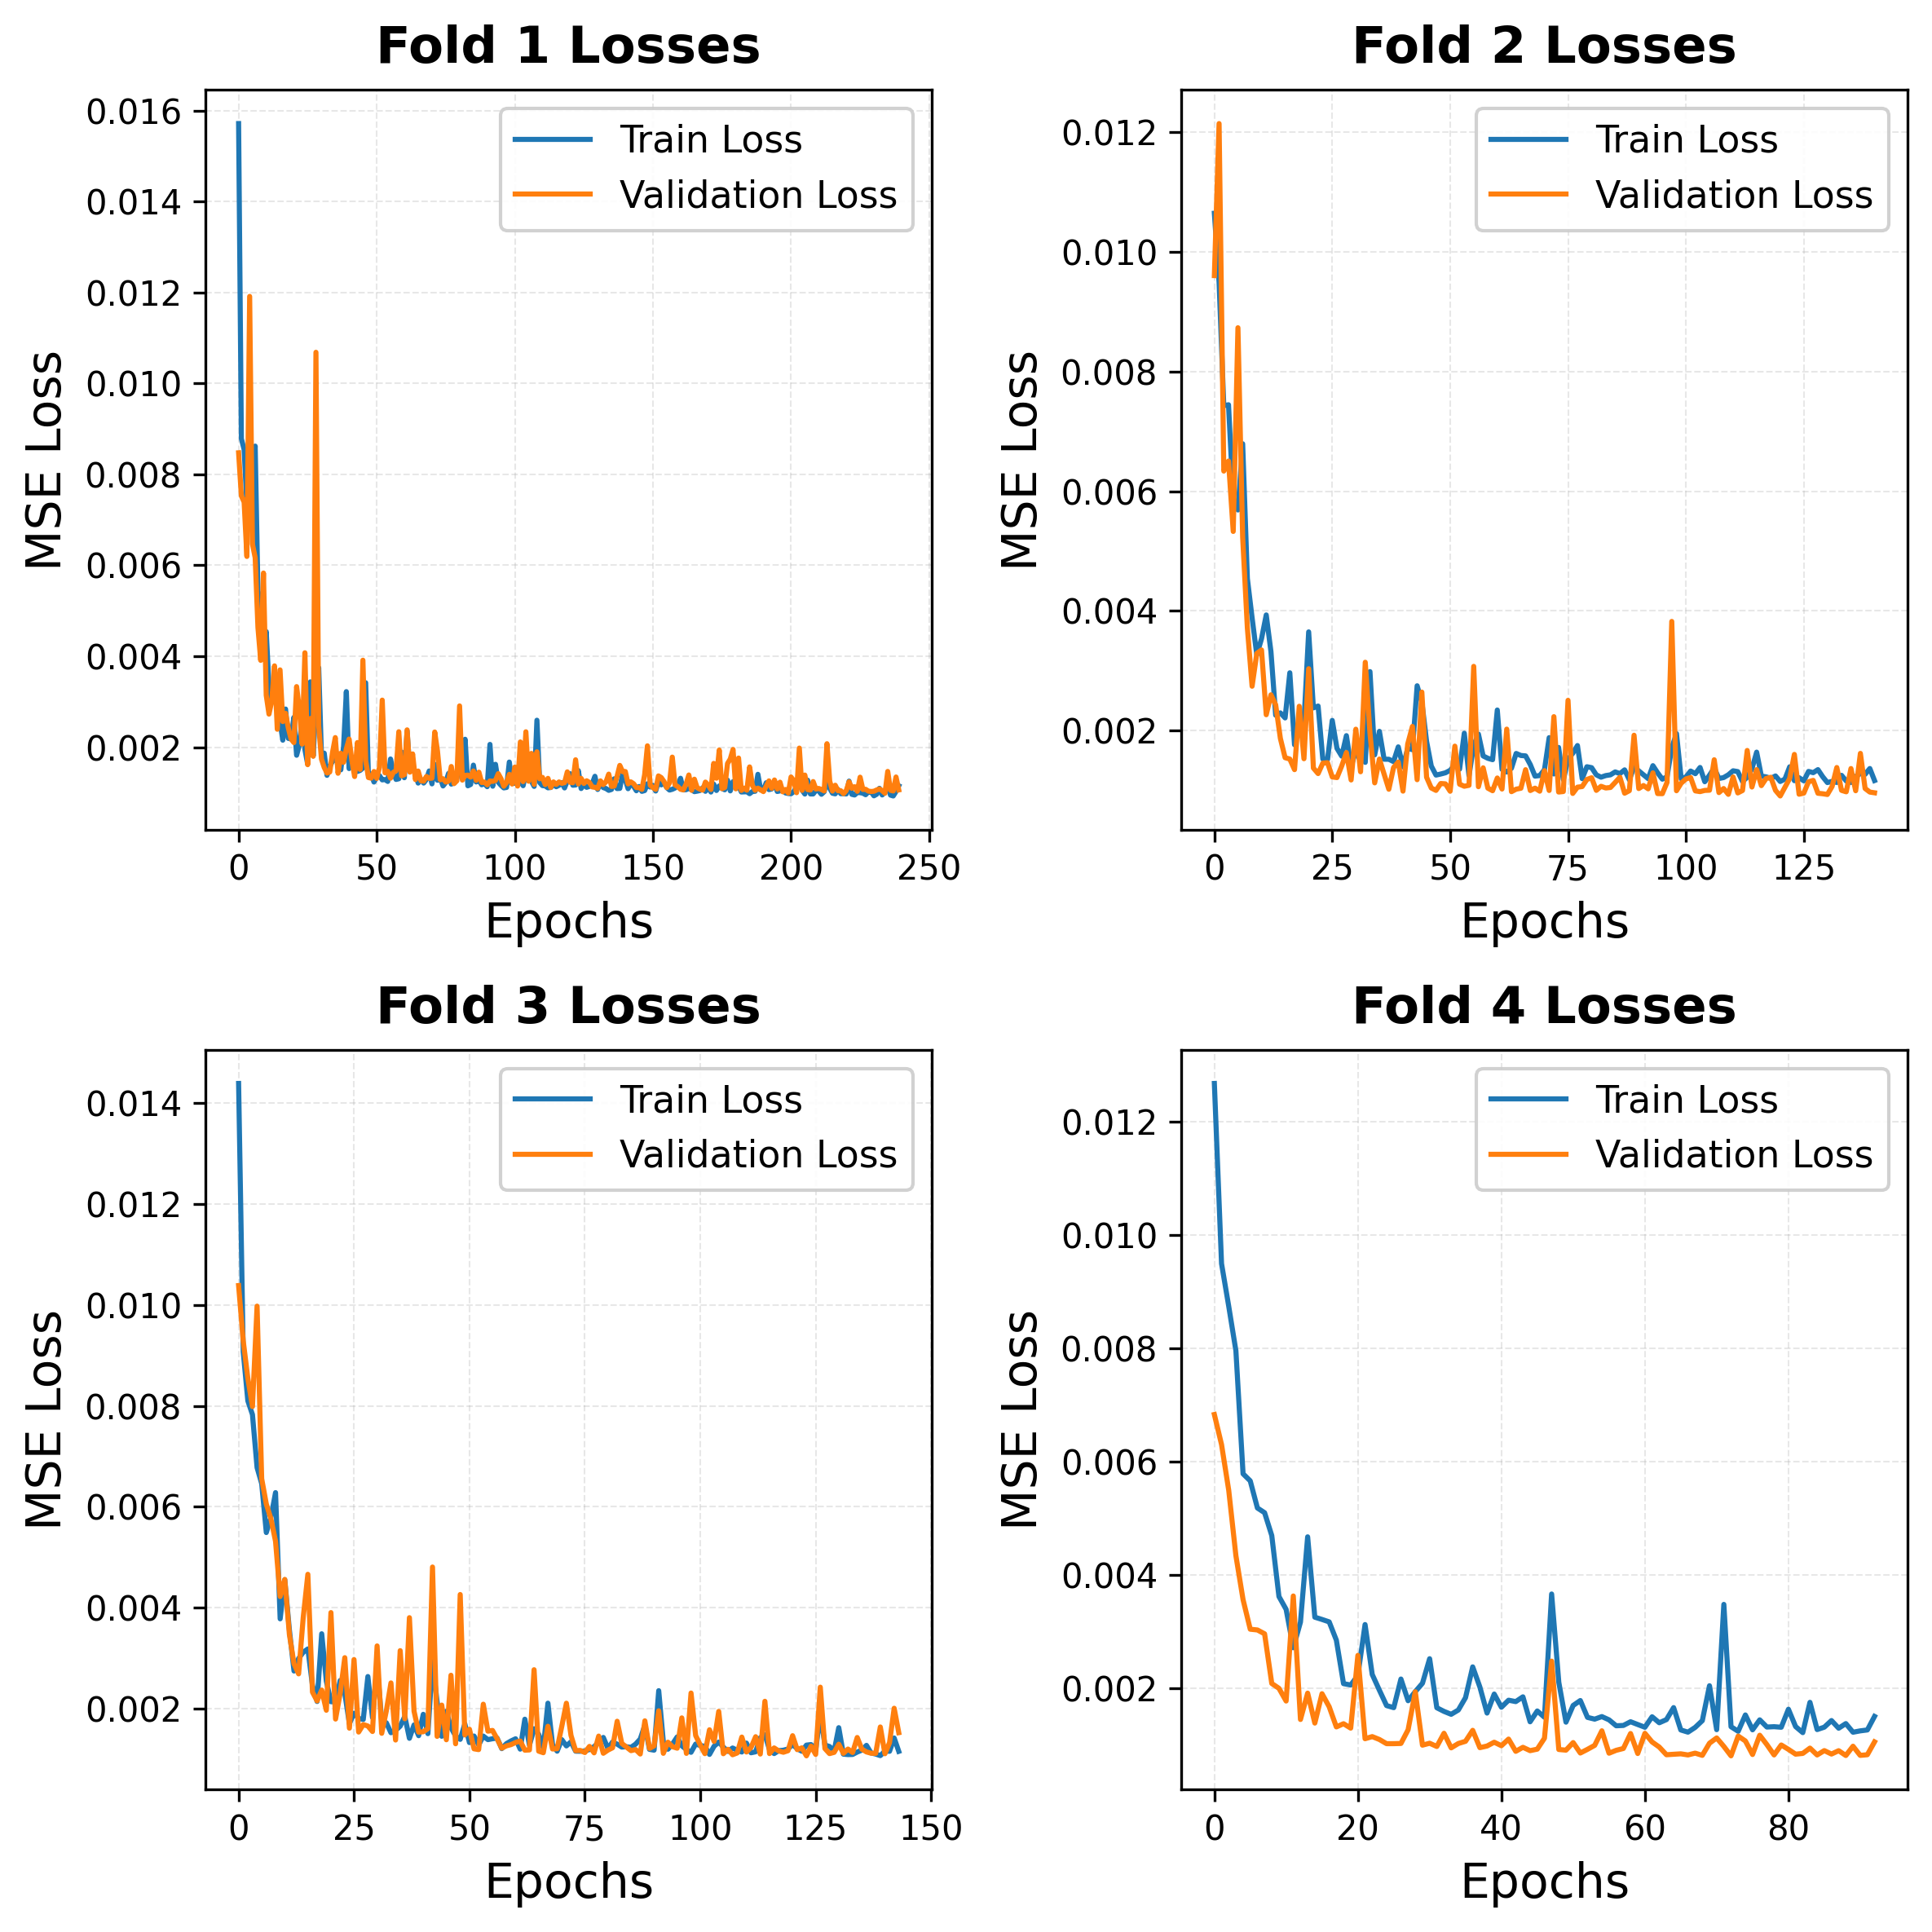

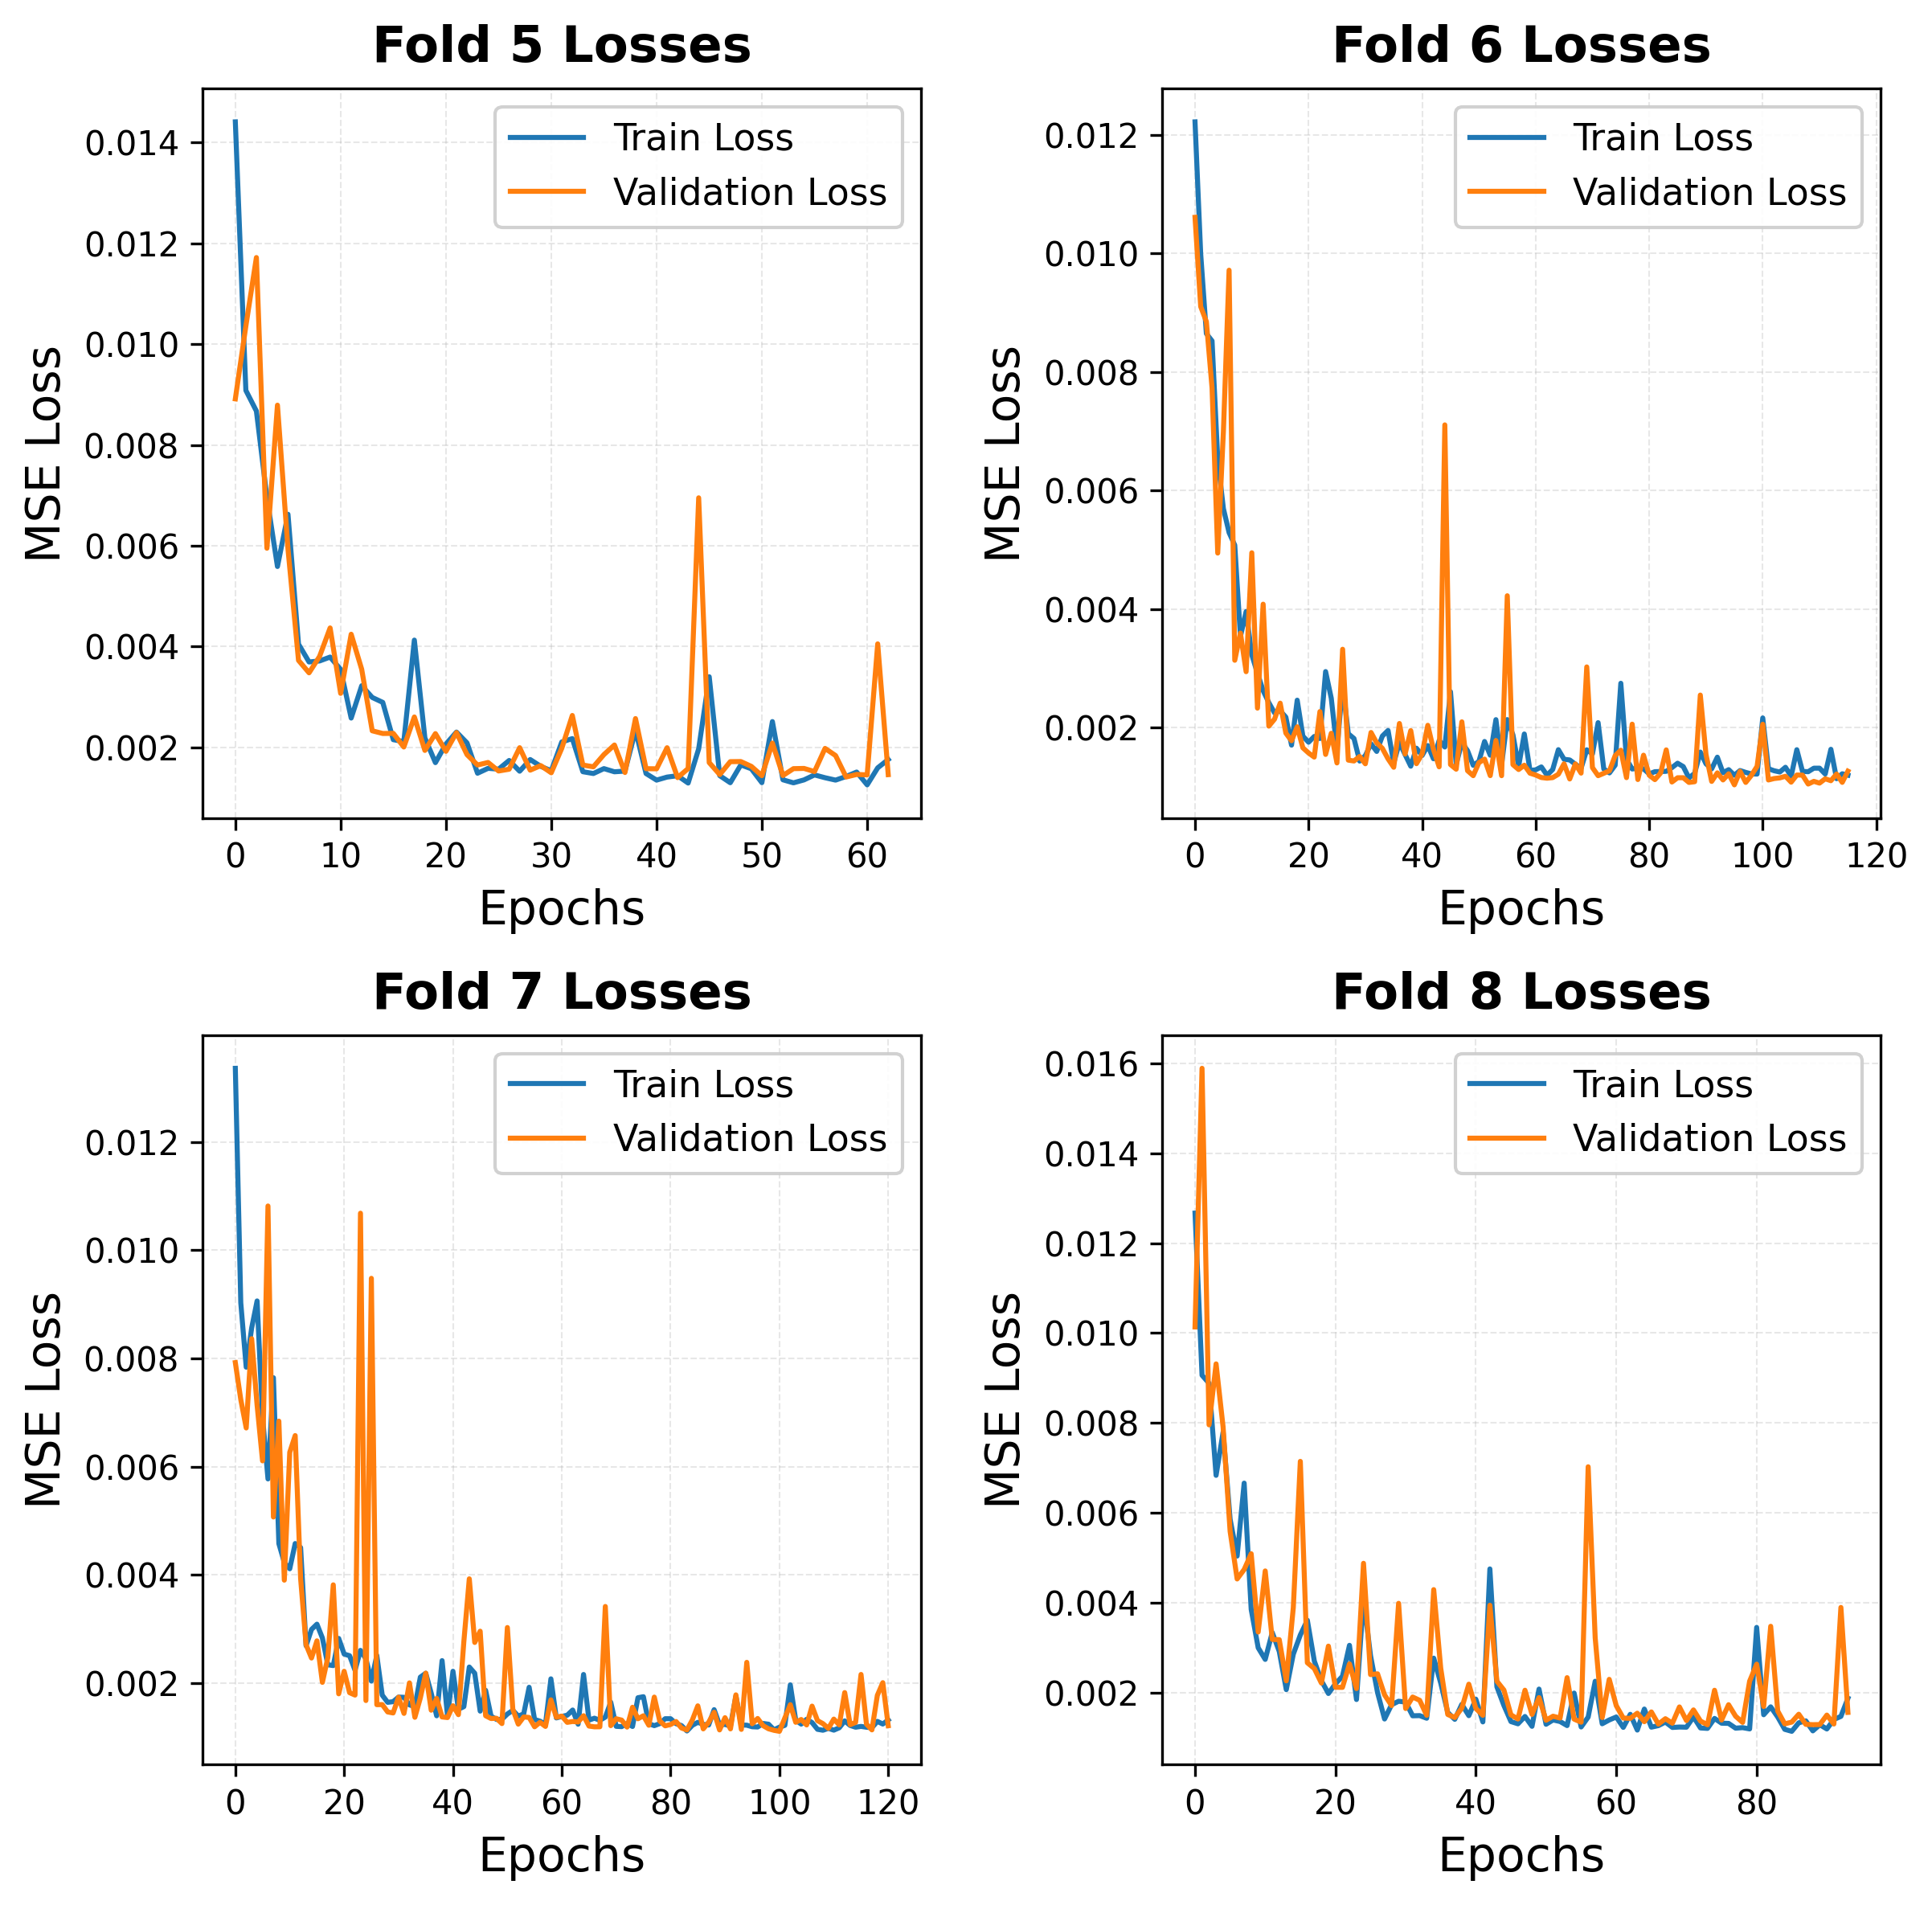

In [23]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300

num_folds = len(train_losses_per_fold)

# -------- First 2x2 figure (folds 1–4) --------
fig1, axs1 = plt.subplots(2, 2, figsize=(8, 8), facecolor='white')
axs1 = axs1.flatten()

for i in range(4):
    axs1[i].plot(train_losses_per_fold[i], label='Train Loss', linewidth=1.5)
    axs1[i].plot(val_losses_per_fold[i], label='Validation Loss', linewidth=1.5)
    axs1[i].set_title(f'Fold {i+1} Losses', fontsize=15, fontweight='bold', pad=8)
    axs1[i].set_xlabel('Epochs', fontsize=14)
    axs1[i].set_ylabel('MSE Loss', fontsize=14)
    axs1[i].legend(fontsize=11, framealpha=0.9)
    axs1[i].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    axs1[i].tick_params(axis='both', labelsize=10)
    
    # KEEP ALL SPINES (for box) - removed the spine visibility lines
    # All spines visible by default

plt.tight_layout()
plt.show()


# -------- Second 2x2 figure (folds 5–8) --------
fig2, axs2 = plt.subplots(2, 2, figsize=(8, 8), facecolor='white')
axs2 = axs2.flatten()

for i in range(4, min(8, num_folds)):
    idx = i - 4
    axs2[idx].plot(train_losses_per_fold[i], label='Train Loss', linewidth=1.5)
    axs2[idx].plot(val_losses_per_fold[i], label='Validation Loss', linewidth=1.5)
    axs2[idx].set_title(f'Fold {i+1} Losses', fontsize=15, fontweight='bold', pad=8)
    axs2[idx].set_xlabel('Epochs', fontsize=14)
    axs2[idx].set_ylabel('MSE Loss', fontsize=14)
    axs2[idx].legend(fontsize=11, framealpha=0.9)
    axs2[idx].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    axs2[idx].tick_params(axis='both', labelsize=10)
    
    # KEEP ALL SPINES (for box) - removed the spine visibility lines
    # All spines visible by default

plt.tight_layout()
plt.show()

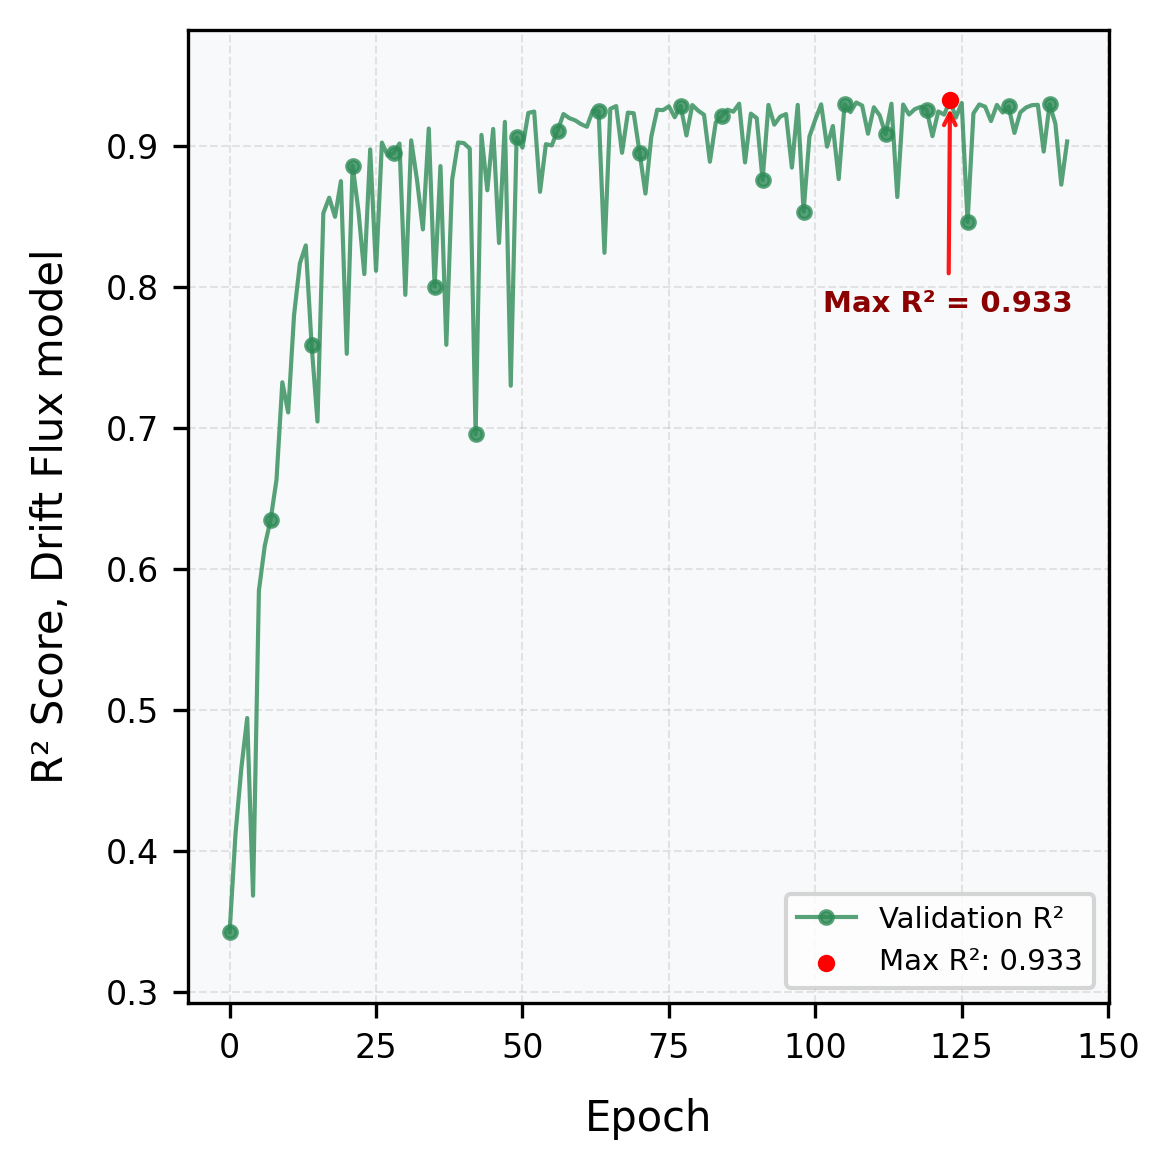

In [24]:
# Validation R² progression across training epochs for the best-performing fold (identified as fold 3 in this case) to visualize how the model's predictive performance evolved during training and to confirm that the best fold indeed showed consistent improvement in R² over epochs.
epochs = range(len(val_r2_per_fold[2]))

# Create figure with 4,4 figure size and 300 dpi
plt.figure(figsize=(4, 4), dpi=300, facecolor='white')

# Plot with enhanced styling
plt.plot(epochs, val_r2_per_fold[2], 
         label="Validation R²", 
         color="#2E8B57",  # Sea green
         linewidth=1,
         marker='o',
         markersize=3,
         markevery=max(1, len(epochs)//20),  # Show markers every ~5% of data points
         alpha=0.8)

# Improve axis styling - adjusted font sizes for 4x4 figure
plt.xlabel("Epoch", fontsize=10, labelpad=8)
plt.ylabel("R² Score, Drift Flux model", fontsize=10, labelpad=8)
# plt.title("Validation R² per Epoch - 1", fontsize=8, pad=10)

# Set y-axis limits with slight padding
plt.ylim(max(0, min(val_r2_per_fold[2]) - 0.05), min(1, max(val_r2_per_fold[2]) + 0.05))

# Add grid for better readability
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Enhance tick labels - adjusted for 4x4
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

# Add legend with better positioning
plt.legend(loc='lower right' if val_r2_per_fold[2][-1] < 0.5 else 'upper right', 
           fontsize=8, 
           framealpha=0.9)

# Tight layout to prevent label cutoff
plt.tight_layout()

# Add a light background to the plot area
ax = plt.gca()
ax.set_facecolor('#f8f9fa')

# Optional: Add a horizontal line at R²=0 for reference
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5, linewidth=1)

# Optional: Highlight the maximum R² value
max_r2 = max(val_r2_per_fold[2])
max_epoch = val_r2_per_fold[2].index(max_r2)
plt.scatter(max_epoch, max_r2, color='red', s=10, zorder=5, 
            label=f'Max R²: {max_r2:.3f}')
plt.annotate(f'Max R² = {max_r2:.3f}', 
             xy=(max_epoch, max_r2),           
             xytext=(max_epoch - len(epochs)*0.15, max_r2 - 0.15),  # Text LEFT side and below
             fontsize=7,
             fontweight='bold',
             color='darkred',
             arrowprops=dict(arrowstyle='->', 
                           color='red', 
                           linewidth=1,
                           alpha=0.9,
                           relpos=(0.5, 0)))

plt.legend(fontsize=7)  # Update legend with max point
plt.show()

### Apply best fold model on test graph set and visualize predictions vs true values

In [25]:
from torch_geometric.loader import DataLoader  # Correct new import

test_data_objects = [
    Data(
        x=torch.tensor(g["X_flat"], dtype=torch.float),
        y=torch.tensor(g["y_flat"], dtype=torch.float),
        edge_index=edge_index,
        num_nodes=g["X_flat"].shape[0]
    ) for g in test_graphs
]

test_loader = DataLoader(test_data_objects, batch_size=1, shuffle=False)

test_y_true, test_y_pred = [], []
test_embeddings = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        h, pred = model(batch.x, batch.edge_index)
        test_embeddings.append(h.cpu())
        test_y_true.append(batch.y.cpu().numpy())
        test_y_pred.append(pred.cpu().numpy())

test_y_true = np.vstack(test_y_true)
test_y_pred = np.vstack(test_y_pred)

mse = mean_squared_error(test_y_true, test_y_pred)
mae = mean_absolute_error(test_y_true, test_y_pred)
r2 = r2_score(test_y_true, test_y_pred)



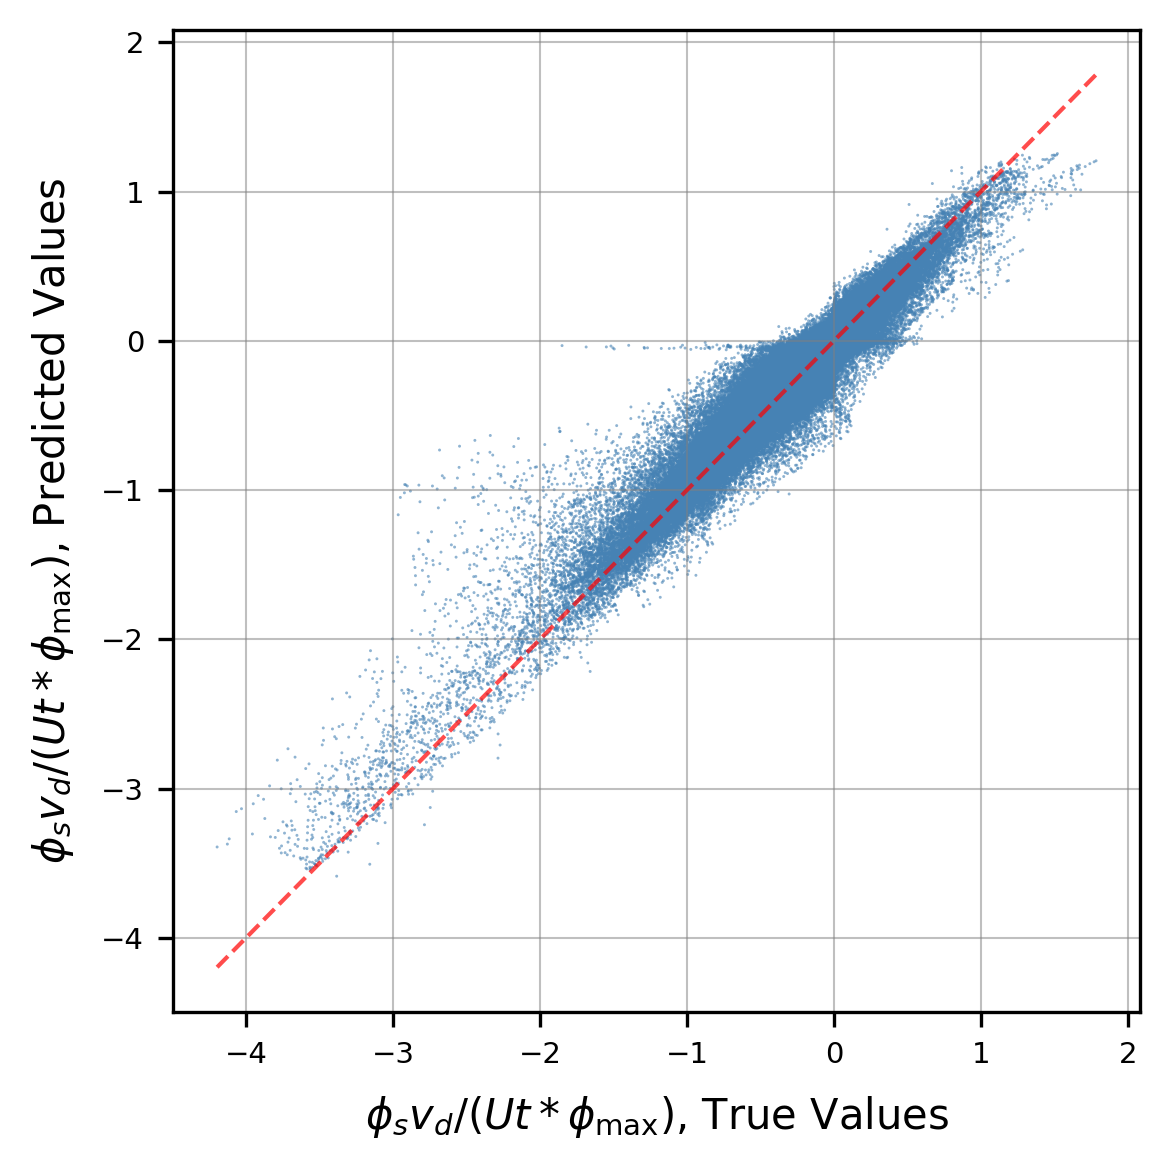

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Flatten arrays (just in case)
y_true = test_y_true.flatten()
y_pred = test_y_pred.flatten()

# Create 4x4 figure with 300 dpi
plt.figure(figsize=(4, 4), dpi=300, facecolor='white')

# Scatter plot
plt.scatter(y_true, y_pred, 
            s=0.5,
            alpha=0.6, 
            c='steelblue',
            edgecolors='none')

# Perfect line (y=x)
plt.plot([y_true.min(), y_true.max()], 
         [y_true.min(), y_true.max()], 
         'r--', 
         lw=1,
         alpha=0.7)

# Labels
plt.xlabel(r"$\phi_s v_d / (Ut* \phi_{\mathrm{max}})$, True Values", 
           fontsize=10, labelpad=6)
plt.ylabel(r"$\phi_s v_d / (Ut* \phi_{\mathrm{max}})$, Predicted Values", 
           fontsize=10, labelpad=6)

# DEFAULT GRID - solid lines, grey color
plt.grid(True, linestyle='-', color='gray', alpha=0.5, linewidth=0.5)

# Tick labels
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

# KEEP ALL SPINES (closed box) - removed the spine visibility lines
# ax = plt.gca()
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# Optional: Add R² value on plot
r2 = r2_score(y_true, y_pred)
# plt.text(0.05, 0.95, f'R² = {r2:.2f}', 
#          transform=ax.transAxes,
#          fontsize=6,
#          fontweight='bold',
#          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

### drag foroce calculation based on drift flux model

In [ ]:
graphs_test = []

for sample in data:
    if "t3" in sample["filename"]:   # pick test graphs
        df = sample["data"]
        
        # Print the 'alp_vd' column
        # print(df['fd_y'])
        
        X = df[feature_cols].values.reshape(ny, nx, -1)
        y = df[label_cols].values.reshape(ny, nx, -1)
        X_flat = X.reshape(-1, X.shape[2])
        y_flat = y.reshape(-1, 1)

        graphs_test.append({
            "X_flat": X_flat,
            "y_flat": y_flat,
            "df": df,              # include full DataFrame for drag calc
            "filename": sample["filename"]
        })
fd_true = []

for g in graphs_test:  # graphs_test already only has "t3" files
    fd_true.append(g['df']['fd_y'].values)  # get numpy array
# Combine all arrays into one
fd_true = np.hstack(fd_true)

alp_max = 0.63
g = 9.81

# Flatten quantities for all graphs into 1D arrays
Ut_all      = np.hstack([g["df"]["ut"].values for g in graphs_test])
alp_all     = np.hstack([g["df"]["solid-vof"].values for g in graphs_test]) * alp_max
u_slip_all  = np.hstack([g["df"]["u_slip_y"].values for g in graphs_test]) * Ut_all
tau_p_all   = np.hstack([g["df"]["tau_p_tilde"].values for g in graphs_test])

# Flatten test_y_true from (N,1) to (N,)
alp_vd_physical_all = test_y_pred.flatten() * Ut_all*alp_max

# Compute drag force elementwise
fd_model_all_true = (alp_all * u_slip_all + alp_vd_physical_all) / (tau_p_all * g)

fd_true = np.round(fd_true, 2)
fd_model_all_true = np.round(fd_model_all_true, 2)
r2_fd = r2_score(fd_true, fd_model_all_true)
# print(f"R² between fd_model_all_true and fd_true: {r2_fd:.2f}")

In [ ]:
# Create 4x4 figure with 300 dpi
plt.figure(figsize=(4, 4), dpi=300, facecolor='white')

# Scatter plot - very small markers
plt.scatter(fd_true, fd_model_all_true, 
            s=0.5,                    # Small points
            alpha=0.6, 
            color='steelblue',
            edgecolors='none')

# Perfect line (y=x)
plt.plot([fd_true.min(), fd_true.max()], 
         [fd_true.min(), fd_true.max()], 
         'r--', 
         lw=1,
         alpha=0.7)

# Labels - adjusted font size
plt.xlabel(r"$\overline{F_{d_y}} / (\rho_s g)$  (fine grid)", 
           fontsize=10, labelpad=6)
plt.ylabel(r"$\overline{F_{d_y}} / (\rho_s g)$  (Drift Flux model)", 
           fontsize=10, labelpad=6)

# DEFAULT GRID - solid lines, grey color
plt.grid(True, linestyle='-', color='gray', alpha=0.5, linewidth=0.5)

# Tick labels
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

# KEEP ALL SPINES (closed box)
# All spines visible by default

plt.tight_layout()
plt.show()